In [2]:
from pandas import read_csv

In [38]:
dataset = read_csv('data.csv')
types = ['Oddiy kompyuter', "Office kompyuterlar", "Programming kompyuterlar", 'Gaming kompyuter']
keys = dataset.keys()

In [39]:
dataset

,Narxi,RAM,Protsessor chastotasi,Videokarta,class
0,350,4,2.4,256,0
1,300,4,2.4,256,0
2,300,4,2.8,256,0
3,460,4,4.0,1024,0
4,330,4,3.6,256,0
5,370,4,2.6,512,0
6,330,6,2.4,512,0
7,250,3,1.3,256,0
8,270,4,1.2,256,0
9,600,4,3.6,2048,1


In [54]:
dataset.shape

(40, 5)

In [41]:
X = dataset.values[:, :3:2]
Y = dataset.values[:, -1]

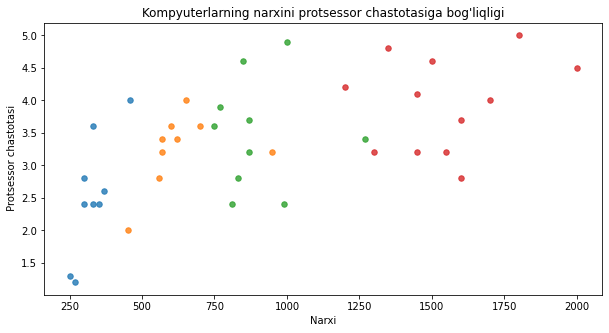

In [61]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 5))

plt.scatter(*X[Y==0].T, s=30, alpha=0.8)
plt.scatter(*X[Y==1].T, s=30, alpha=0.8)
plt.scatter(*X[Y==2].T, s=30, alpha=0.8)
plt.scatter(*X[Y==3].T, s=30, alpha=0.8)
plt.title("Kompyuterlarning narxini protsessor chastotasiga bog'liqligi")
plt.xlabel(keys[0])
plt.ylabel(keys[2])
plt.show()

In [67]:
X_train = dataset.values[:, :-1]
Y_train = dataset.values[:, -1]

In [68]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, test_size=0.15)

In [69]:
y_train, y_test

(array([3., 3., 0., 3., 1., 0., 0., 2., 3., 2., 1., 1., 3., 0., 3., 3., 0.,
        1., 1., 2., 0., 0., 2., 2., 1., 2., 3., 3., 1., 2., 3., 0., 3., 2.]),
 array([1., 3., 1., 2., 2., 0.]))

In [82]:
from sklearn.linear_model import LogisticRegression
logisticRegr = LogisticRegression()

In [83]:
logisticRegr.fit(x_train, y_train)
predictions = logisticRegr.predict(x_train)

c:\users\3d\appdata\local\programs\python\python39\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [93]:
score = logisticRegr.score(x_train, y_train)
print("Aniqlik:", score)

Aniqlik: 0.9117647058823529


In [94]:
score = logisticRegr.score(x_test, y_test)
print("Aniqlik:", score)

Aniqlik: 0.6666666666666666


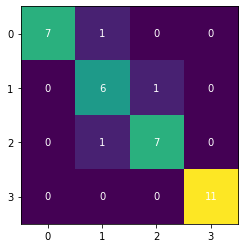

In [91]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train, predictions)
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(cm)
ax.xaxis.set(ticks=range(4))
ax.yaxis.set(ticks=range(4))
ax.set_ylim(3.5, -0.5)
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white')
plt.show()

In [92]:
from sklearn.metrics import classification_report
print(classification_report(y_train, predictions))

              precision    recall  f1-score   support

         0.0       1.00      0.88      0.93         8
         1.0       0.75      0.86      0.80         7
         2.0       0.88      0.88      0.88         8
         3.0       1.00      1.00      1.00        11

    accuracy                           0.91        34
   macro avg       0.91      0.90      0.90        34
weighted avg       0.92      0.91      0.91        34

